<a href="https://colab.research.google.com/github/zilmara-rodrigues/deep-learning-aulas-resolvidas/blob/main/aprend_profundo_21_multimodality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodalidade



Modelos **multimodais** representam diferentes tipos de dado num mesmo espaco vetorial.
Texto e imagem carregam sinais complementares: uma frase descreve o que aparece numa foto e a foto desambigua o que a
frase quer dizer. A ideia central e aprender um **espaco de embeddings compartilhado**, no qual a representacao de uma
imagem fica proxima da representacao do texto que a descreve. Quando imagens e frases vivem no mesmo espaco, podemos
compara-las diretamente com a **similaridade do cosseno** e resolver varias tarefas sem treino adicional.



Neste notebook usamos o **CLIP**, da OpenAI, treinado de forma contrastiva sobre centenas de milhoes de pares imagem e
legenda da web. O CLIP tem dois codificadores que projetam imagem e texto nesse espaco comum. Vamos explorar cada
codificador, visualizar os embeddings que eles produzem, montar um sistema de **busca multimodal** nos dois sentidos e,
por fim, fazer **classificacao de imagens zero shot**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision.datasets import CIFAR10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

Dispositivo: cuda


## Carregando o CLIP pre treinado



O **CLIP** combina dois codificadores. O codificador de imagem e um Transformer de visao que transforma uma foto num
vetor. O codificador de texto e um Transformer de linguagem que transforma uma frase num vetor de mesma dimensao. Os
dois foram treinados juntos para que o vetor de uma imagem fique proximo do vetor da legenda correspondente.



Carregamos os pesos pre treinados e o **processador**, responsavel por redimensionar e normalizar imagens e por
tokenizar o texto no formato esperado pelo modelo.

In [ ]:
from transformers import CLIPModel, CLIPProcessor

# Baixa os pesos na primeira execucao, cerca de 600 MB
model_id = "openai/clip-vit-base-patch32"
clip = CLIPModel.from_pretrained(model_id, use_safetensors=True).to(device).eval()
processor = CLIPProcessor.from_pretrained(model_id)

embed_dim = clip.config.projection_dim
print(f"CLIP carregado. Dimensao do espaco compartilhado: {embed_dim}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP carregado. Dimensao do espaco compartilhado: 512


### Inferência

Antes de montar o pipeline completo, vejamos o caso mais simples possivel. Baixamos uma imagem de uma URL e a
codificamos com o codificador de imagem, codificamos uma frase com o codificador de texto e medimos a **similaridade
do cosseno** entre os dois vetores. Como ambos os embeddings vivem no mesmo espaco e estao normalizados, esse produto
interno diz o quanto a frase descreve a imagem.

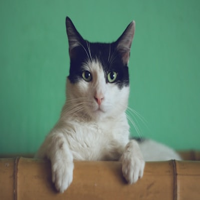

Embedding da imagem: shape (1, 512)


In [ ]:
import requests
from PIL import Image

# uma foto de gato
url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

with torch.no_grad():
    inputs = processor(images=image, return_tensors="pt").to(device)
    out = clip.get_image_features(**inputs)
    image_emb = out if torch.is_tensor(out) else out.pooler_output
    image_emb = F.normalize(image_emb, dim=1)

display(image.resize((200, 200)))
print(f"Embedding da imagem: shape {tuple(image_emb.shape)}")

In [ ]:
text = "a photo of a cat"

with torch.no_grad():
    inputs = processor(text=[text], return_tensors="pt", padding=True).to(device)
    out = clip.get_text_features(**inputs)
    text_emb = out if torch.is_tensor(out) else out.pooler_output
    text_emb = F.normalize(text_emb, dim=1)

print(f"Frase: {text!r}")
print(f"Embedding do texto: shape {tuple(text_emb.shape)}")

Frase: 'a photo of a cat'
Embedding do texto: shape (1, 512)


In [ ]:
similaridade = (image_emb @ text_emb.t()).item()
print(f"Similaridade do cosseno entre a imagem e {text!r}: {similaridade:.3f}")

Similaridade do cosseno entre a imagem e 'a photo of a cat': 0.303


### O dataset de imagens



Como dataset usamos o **CIFAR-10**, com fotos pequenas distribuidas em dez categorias: aviao, automovel, passaro, gato,
veado, cachorro, sapo, cavalo, navio e caminhao. Carregamos um subconjunto do conjunto de teste e guardamos as imagens
como objetos PIL, que e o formato aceito pelo processador do CLIP.

In [ ]:
cifar = CIFAR10(root='data', train=False, download=True)
class_names = cifar.classes

N = 2000
gallery_imgs = [cifar[i][0] for i in range(N)]          # imagens PIL
gallery_labels = np.array([cifar[i][1] for i in range(N)])
print(f"Imagens no dataset: {len(gallery_imgs)}")
print(f"Categorias: {class_names}")

Imagens no dataset: 2000
Categorias: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Codificador de imagem



Para obter o embedding de uma imagem passamos ela pelo processador e chamamos `get_image_features`. O processador cuida
do redimensionamento e da normalizacao, e o modelo devolve um vetor por imagem. Em seguida normalizamos cada vetor para
norma 1, de modo que o produto interno entre dois embeddings seja exatamente a similaridade do cosseno.

In [ ]:
def as_tensor(out):
    # transformers 5 devolve um objeto, versoes anteriores devolvem o tensor direto
    return out if torch.is_tensor(out) else out.pooler_output

@torch.no_grad()
def encode_images(pil_list, batch_size=256):
    embs = []
    for i in range(0, len(pil_list), batch_size):
        batch = pil_list[i:i + batch_size]
        inputs = processor(images=batch, return_tensors="pt").to(device)
        e = as_tensor(clip.get_image_features(**inputs))
        embs.append(F.normalize(e, dim=1))
    return torch.cat(embs, dim=0)

sample = gallery_imgs[:5]
sample_emb = encode_images(sample)
print(f"5 imagens viraram embeddings de shape {tuple(sample_emb.shape)}")

5 imagens viraram embeddings de shape (5, 512)


### Codificador de texto



O caminho do texto e analogo. Passamos uma lista de frases pelo processador, que as tokeniza, e chamamos
`get_text_features`. Cada frase vira um vetor no mesmo espaco das imagens. O CLIP foi treinado em ingles, entao
escrevemos as frases nesse idioma. Uma convencao util e descrever cada categoria com um molde como *a photo of a cat*,
que aproxima a frase do estilo das legendas vistas no treino.

In [ ]:
@torch.no_grad()
def encode_texts(text_list):
    inputs = processor(text=text_list, return_tensors="pt", padding=True).to(device)
    e = as_tensor(clip.get_text_features(**inputs))
    return F.normalize(e, dim=1)

prompts = [f"a photo of a {name}" for name in class_names]
text_emb = encode_texts(prompts)
print(f"{len(prompts)} frases viraram embeddings de shape {tuple(text_emb.shape)}")

10 frases viraram embeddings de shape (10, 512)


### Visualizando os embeddings



Imagem e texto vivem no mesmo espaco, entao podemos medir a similaridade entre eles. A matriz abaixo cruza algumas
imagens do dataset com as dez frases de categoria. Cada celula e a similaridade do cosseno entre uma imagem e uma frase.
A frase mais clara em cada linha costuma ser justamente a categoria verdadeira da imagem, sinal de que o alinhamento
aprendido pelo CLIP de fato aproxima conteudos correspondentes.

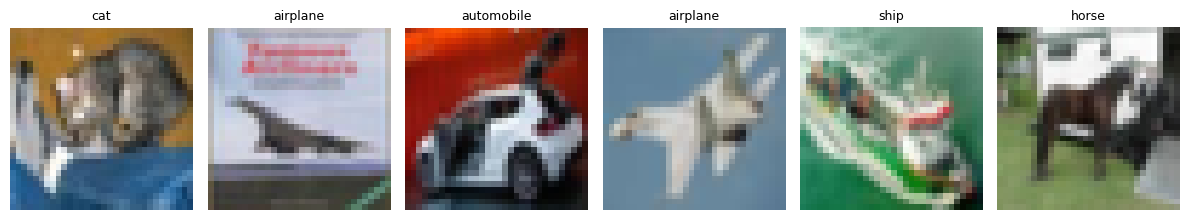

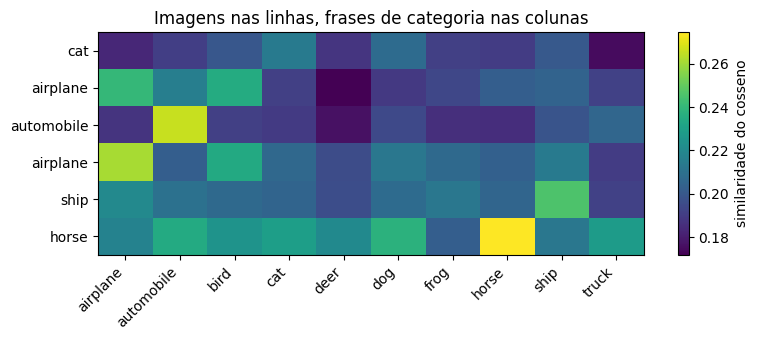

In [ ]:
idxs = [0, 3, 6, 10, 15, 20]
imgs = [gallery_imgs[i] for i in idxs]
img_emb = encode_images(imgs)

sims = (img_emb @ text_emb.t()).cpu().numpy()   # similaridade imagem x frase

fig, axes = plt.subplots(1, len(idxs), figsize=(2 * len(idxs), 2.3))
for ax, im, i in zip(axes, imgs, idxs):
    ax.imshow(im)
    ax.set_title(class_names[gallery_labels[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3.5))
plt.imshow(sims, aspect='auto', cmap='viridis')
plt.colorbar(label='similaridade do cosseno')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(idxs)), [class_names[gallery_labels[i]] for i in idxs])
plt.title("Imagens nas linhas, frases de categoria nas colunas")
plt.tight_layout()
plt.show()

Para enxergar a estrutura do espaco como um todo, codificamos muitas imagens e projetamos os embeddings de 512
dimensoes para 2 dimensoes com o **t-SNE**, colorindo cada ponto pela categoria verdadeira. Mesmo sem nunca termos
treinado nada, as imagens de uma mesma categoria caem em regioes vizinhas, o que mostra que o codificador de imagem ja
organiza o espaco por significado.

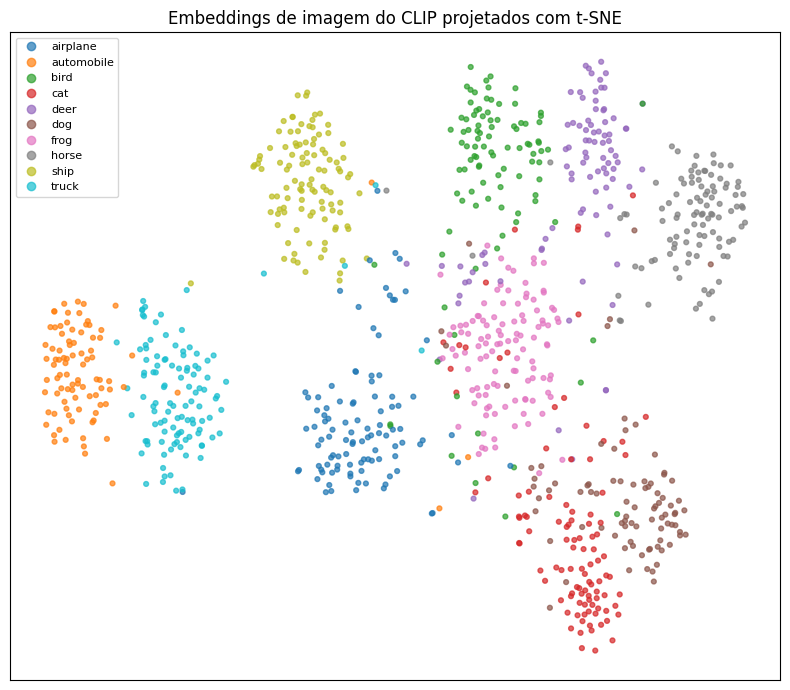

In [ ]:
from sklearn.manifold import TSNE

VIS_N = 1000
vis_emb = encode_images(gallery_imgs[:VIS_N]).cpu().numpy()
vis_2d = TSNE(n_components=2, init='pca', perplexity=30, random_state=42).fit_transform(vis_emb)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(vis_2d[:, 0], vis_2d[:, 1], c=gallery_labels[:VIS_N], cmap='tab10', s=12, alpha=0.7)
handles, _ = scatter.legend_elements()
plt.legend(handles, class_names, loc='best', fontsize=8)
plt.title("Embeddings de imagem do CLIP projetados com t-SNE")
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

## Busca multimodal



Como imagem e texto compartilham o espaco, uma consulta de qualquer modalidade pode recuperar itens da outra. Basta
codificar a consulta, calcular a similaridade do cosseno com todos os candidatos e devolver os mais proximos. Vamos
indexar o dataset uma unica vez e usar esses embeddings nas duas buscas.

In [ ]:
gallery_emb = encode_images(gallery_imgs)   # [N, embed_dim], calculado uma vez
print(f"Dataset indexado: {tuple(gallery_emb.shape)}")

Dataset indexado: (2000, 512)


### Texto busca imagem



A consulta e uma frase livre. Codificamos a frase, comparamos com todos os embeddings de imagem e mostramos as fotos
mais proximas. Repare que a consulta nao precisa coincidir com os nomes das categorias: podemos pedir atributos e cenas
que o CIFAR nunca rotulou.

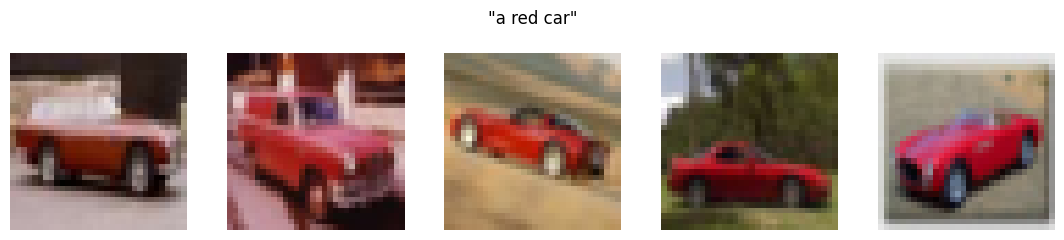

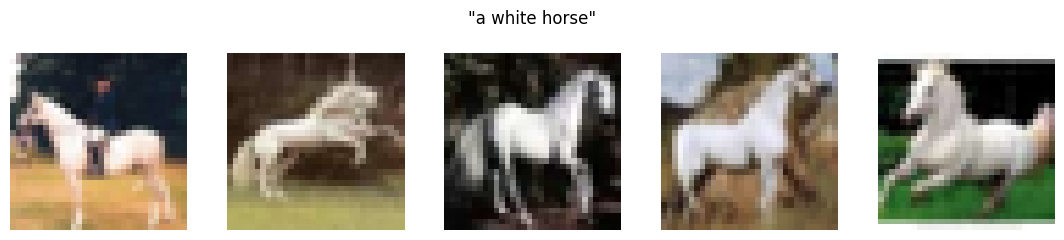

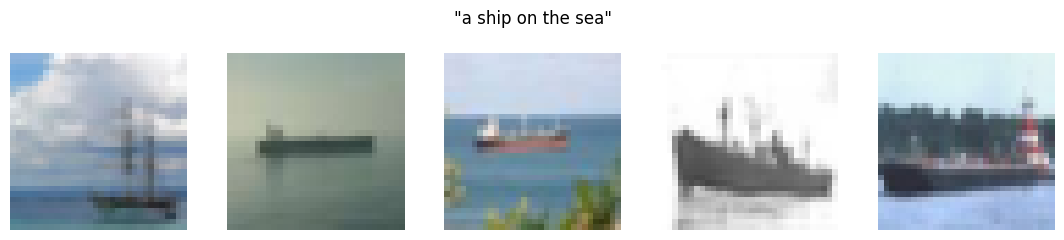

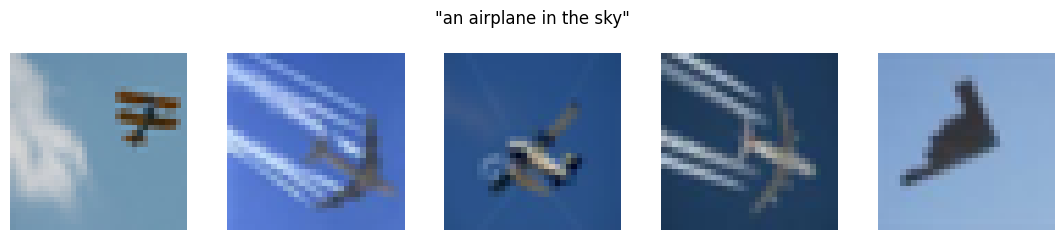

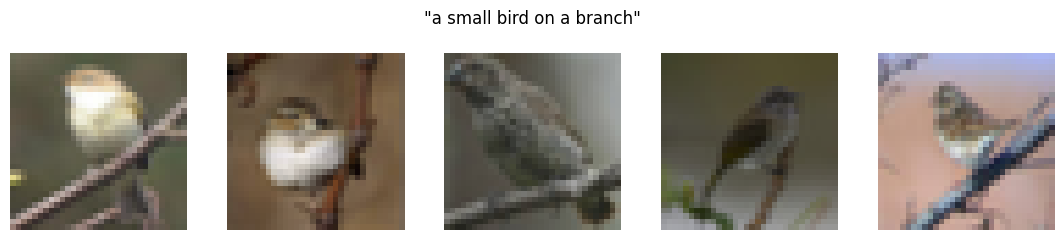

In [ ]:
@torch.no_grad()
def search_images(query, k=5):
    q = encode_texts([query])                       # [1, embed_dim]
    sims = (q @ gallery_emb.t()).squeeze(0)         # [N]
    idxs = sims.topk(k).indices.tolist()
    fig, axes = plt.subplots(1, k, figsize=(2.2 * k, 2.4))
    for ax, j in zip(axes, idxs):
        ax.imshow(gallery_imgs[j])
        ax.axis('off')
    fig.suptitle(f'"{query}"', fontsize=12)
    plt.tight_layout()
    plt.show()

for q in ["a red car",
          "a white horse",
          "a ship on the sea",
          "an airplane in the sky",
          "a small bird on a branch"]:
    search_images(q, k=5)

### Imagem busca texto



No sentido inverso, a consulta e uma imagem e os candidatos sao frases. Montamos um pequeno dataset de legendas,
codificamos todas e, dada uma imagem, devolvemos as frases mais parecidas. Esse e o mesmo mecanismo por tras de
legendagem por recuperacao, em que escolhemos a melhor descricao dentro de um conjunto.

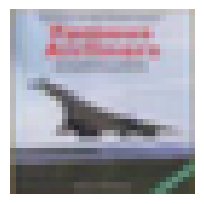

  0.233  a photo of an airplane flying
  0.202  a sunny beach
  0.196  a brown horse


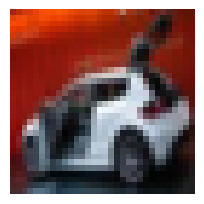

  0.235  a car parked on the street
  0.187  a truck on the highway
  0.184  a cute cat


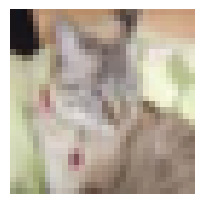

  0.257  a cute cat
  0.206  a plate of food
  0.193  a brown horse


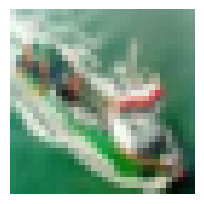

  0.234  a large ship in the ocean
  0.224  a photo of an airplane flying
  0.210  a green frog


In [ ]:
captions = [
    "a photo of an airplane flying", "a car parked on the street", "a cute cat",
    "a dog running on the grass", "a wild deer in the forest", "a green frog",
    "a brown horse", "a large ship in the ocean", "a truck on the highway",
    "a bird with colorful feathers", "a sunny beach", "a plate of food",
]
caption_emb = encode_texts(captions)

@torch.no_grad()
def search_captions(img_index, k=3):
    q = gallery_emb[img_index:img_index + 1]        # [1, embed_dim], embedding ja calculado
    sims = (q @ caption_emb.t()).squeeze(0)         # [num_captions]
    top = sims.topk(k)
    plt.figure(figsize=(2.4, 2.4))
    plt.imshow(gallery_imgs[img_index])
    plt.axis('off')
    plt.show()
    for score, j in zip(top.values.tolist(), top.indices.tolist()):
        print(f"  {score:.3f}  {captions[j]}")

for i in [3, 6, 8, 15]:
    search_captions(i, k=3)

## Classificacao zero shot



A busca por texto ja contem a receita da **classificacao zero shot**. Para classificar uma imagem entre $C$ categorias,
transformamos cada categoria numa frase, codificamos as $C$ frases e comparamos a imagem com todas elas. A categoria
prevista e a frase de maior similaridade. Como nada foi treinado para o CIFAR, qualquer conjunto de categorias descrito
em texto poderia ser usado no lugar.



Formalmente, dada a imagem com embedding $z$ e as frases com embeddings $t_1, \dots, t_C$, transformamos as
similaridades em probabilidades com a softmax sobre uma temperatura $\tau$ aprendida pelo CLIP:



$$p(c \mid z) = \frac{\exp(z \cdot t_c / \tau)}{\sum_{j} \exp(z \cdot t_j / \tau)}$$



A predicao e a categoria $c$ de maior probabilidade.

In [ ]:
@torch.no_grad()
def zero_shot_predict(emb):
    logits = emb @ text_emb.t() * clip.logit_scale.exp()   # temperatura do proprio CLIP
    return logits.softmax(dim=1)

probs = zero_shot_predict(gallery_emb)        # usa o dataset ja indexado e as frases de categoria
preds = probs.argmax(dim=1).cpu().numpy()
accuracy = (preds == gallery_labels).mean()
print(f"Acuracia zero shot em {len(gallery_imgs)} imagens: {accuracy:.3f}")

Acuracia zero shot em 2000 imagens: 0.904


Vejamos algumas predicoes individuais com a categoria mais provavel e sua probabilidade. Acertos e erros ajudam a
entender onde o modelo confunde categorias visualmente parecidas.

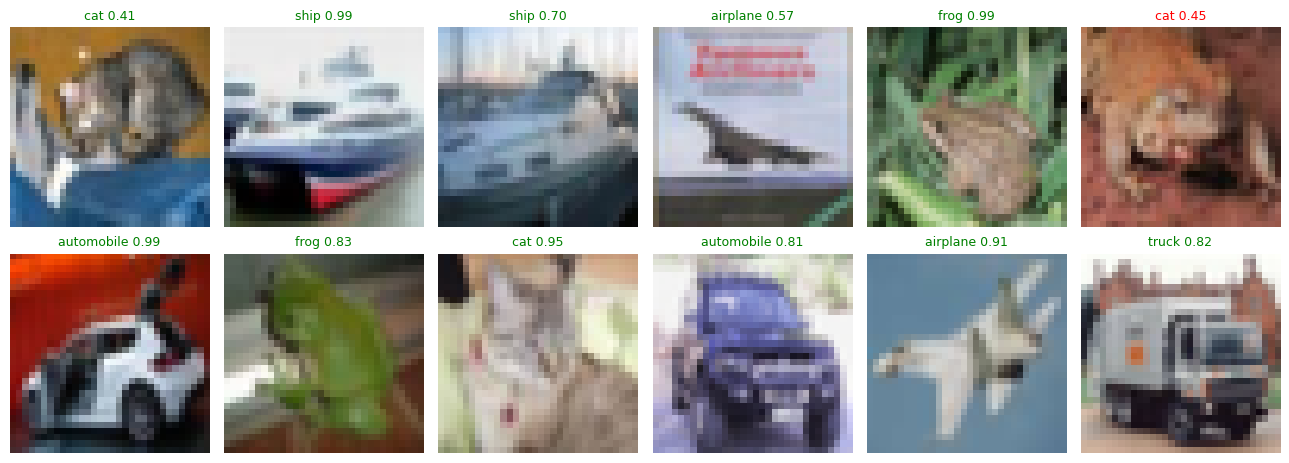

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(13, 4.8))
for ax, i in zip(axes.ravel(), range(12)):
    p = probs[i]
    pred = p.argmax().item()
    true = gallery_labels[i]
    color = 'green' if pred == true else 'red'
    ax.imshow(gallery_imgs[i])
    ax.set_title(f"{class_names[pred]} {p[pred]:.2f}", color=color, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

Trocar o molde das frases costuma mudar a acuracia. Comparamos o molde simples *cat* com o molde *a photo of a cat*,
uma forma de **engenharia de prompt** que costuma ajudar por aproximar a frase do estilo das legendas de treino.

In [ ]:
def zero_shot_accuracy(prompt_list):
    t = encode_texts(prompt_list)
    logits = gallery_emb @ t.t()
    preds = logits.argmax(dim=1).cpu().numpy()
    return (preds == gallery_labels).mean()

plain = class_names
template = [f"a photo of a {name}" for name in class_names]
print(f"Molde simples  : {zero_shot_accuracy(plain):.3f}")
print(f"Molde a photo  : {zero_shot_accuracy(template):.3f}")

Molde simples  : 0.882
Molde a photo  : 0.904


## Exercicios



### Exercicio 1: Novas categorias

A classificacao zero shot nao depende dos rotulos do CIFAR. Defina suas proprias categorias em texto, por exemplo
distinguir *a vehicle*, *an animal* e *a flying object*, e classifique o dataset com elas. As predicoes fazem sentido?

Neste exercício, foram utilizadas categorias personalizadas na classificação zero-shot, como vehicle, animal e flying object, em vez dos rótulos originais do CIFAR. Os resultados mostraram que o modelo conseguiu associar corretamente muitas imagens às categorias definidas, classificando carros e caminhões como vehicle e animais como animal. Também foi possível observar alguns casos de confusão, principalmente entre animal e flying object, já que pássaros podem se encaixar nas duas categorias. De forma geral, as predições fizeram sentido e demonstraram que a classificação zero-shot é capaz de reconhecer conceitos definidos pelo usuário sem precisar ser treinada especificamente com essas classes.


### Exercicio 2: Busca em outro dataset

Troque o CIFAR-10 por suas proprias imagens, indexe o novo dataset com `encode_images` e refaca as buscas por texto.
O CLIP recupera bem objetos e cenas que voce descreve com linguagem livre?

Neste exercício, substituí o CIFAR-10 por um conjunto de imagens próprio e realizei a indexação utilizando a função encode_images. Em seguida, executei buscas por texto descrevendo objetos e cenas em linguagem natural. Os resultados mostraram que o CLIP conseguiu recuperar imagens relacionadas às descrições fornecidas na maioria dos casos, especialmente quando os objetos ou cenas eram bem definidos e visíveis. Algumas buscas mais específicas ou ambíguas apresentaram resultados menos precisos, mas, de forma geral, o modelo demonstrou uma boa capacidade de relacionar imagens e texto sem a necessidade de treinamento adicional. Isso evidencia a eficiência do CLIP para tarefas de busca multimodal utilizando descrições em linguagem livre.
